In [1]:
from ovo import db, schedulers, storage, descriptors, descriptors_refolding, design_logic, descriptor_logic, project_logic
from ovo import models_rfdiffusion, Threshold
import os
import time
import itertools

Registering plugin ovo_promb
Registering plugin ovo_proteindj


OVO home /home/username/ovo

In [2]:
project, project_round = project_logic.get_or_create_project_round("OVO Publication Examples 1", "Interface scaffolding")

In [3]:
PDB_ID = "5IUS"

In [4]:
POOL_NAME = "5IUS 500*5 designs PD1 interface with inpaint"
POOL_DESCRIPTION = "PD1 interface, inpaint seq"

workflow = models_rfdiffusion.RFdiffusionScaffoldDesignWorkflow(
    rfdiffusion_params=models_rfdiffusion.RFdiffusionParams(
        input_pdb_paths=[storage.store_input(project.id, f'../../data/inputs/{PDB_ID}.pdb')],
        contigs=['0-30/A119-140/15-40/A63-82/0-30/0 C18-27/C53-68/C111-127'],
        run_parameters='contigmap.inpaint_seq=[A63/A65/A67/A69/A71-72/A76/A79-80/A82/A119-123/A125/A127/A129-130/A133/A135/A137-138/A140]',
        num_designs=1000,
        batch_size=100,
    ),
    protein_mpnn_params=models_rfdiffusion.ProteinMPNNParams(
        num_sequences=5,
        sampling_temp=0.1
    ),
    refolding_params=models_rfdiffusion.RefoldingParams(
        primary_test="af2_model_1_ptm_ft_3rec",
    ),
)
workflow.validate()
workflow.get_table_row()

Workflow     input                                                                 None
             type                                           RFdiffusion scaffold design
RFdiffusion  contigs                  [0-30/A119-140/15-40/A63-82/0-30/0 C18-27/C53-...
             hotspots                                                              None
             model_weights                                                         None
             timesteps                                                               50
             partial_diffusion                                                    False
             num_designs                                                           1000
             cyclic_offset                                                        False
             batch_size                                                             100
             contigmap_length                                                      None
             inpaint_seq        

## Select project and submit workflow

In [5]:
print(schedulers.keys())

SCHEDULER_KEY = 'pbs_singularity'

dict_keys(['pbs_singularity', 'local_singularity', 'local_conda', 'local_single_gpu'])


In [6]:
print(workflow.get_time_estimate(schedulers[SCHEDULER_KEY]))

The pipeline will generate and evaluate **1000 backbone designs**. For a structure of **~1000 residues**, the expected runtime is about **2 minutes** for 1 design. The estimated total runtime including startup is **1.4 days**. Workflow will be parallelized in batches of 100 designs, each batch can run in parallel so the total runtime can be shortened dramatically.


In [7]:
design_job, pool = design_logic.submit_design_workflow(
    # Your initialized workflow settings
    workflow=workflow,
    # Name your pool of designs
    pool_name=POOL_NAME,
    pool_description=POOL_DESCRIPTION,
    # see schedulers for available scheduler keys
    scheduler_key=SCHEDULER_KEY,
    # Project and Round where the Pool will be created
    round_id=project_round.id,
)

Submitting workflow: nextflow run -with-trace trace.txt -work-dir /home/username/ovo/workdir/work /home/username/projects/ovo-open-source/ovo/ovo/pipelines/rfdiffusion-end-to-end --publish_dir output --reference_files_dir /home/username/ovo/reference_files --shared_modules ovo:/home/username/projects/ovo-open-source/ovo/ovo,ovo_promb:/home/username/projects/ovo-open-source/ovo-promb/ovo_promb,ovo_proteindj:/home/username/projects/ovo-proteindj/ovo_proteindj -config /home/username/projects/ovo-open-source/ovo/ovo/pipelines/nextflow_default.config -config /home/username/projects/ovo-open-source/ovo/ovo/pipelines/rfdiffusion-end-to-end/nextflow.config -profile singularity -config /home/username/ovo/nextflow_pbs_singularity.config -ansi-log false -bg --batch_size 100 --rfdiffusion_input_pdb /home/username/ovo/workdir/inputs/b0/7f783f9a486a0698ce0da67f2d525bb9d69bb4/5IUS.pdb --rfdiffusion_num_designs 1000 --rfdiffusion_contig 0-30/A119-140/15-40/A63-82/0-30/0 C18-27/C53-68/C111-127 --rfdiff

In [8]:
print(pool.id)

xeh


### Status of current job

In [9]:
design_logic.get_design_jobs_table(id=pool.id)

Pool  \
                                                     name   
(Pool, id)                                                  
xeh         5IUS 500*5 designs PD1 interface with inpaint   

                                             Job                       \
                           description    status     duration created   
(Pool, id)                                                              
xeh         PD1 interface, inpaint seq  ⏳Running  Not started     now   

            Designs       Workflow                               \
           accepted total    input                         type   
(Pool, id)                                                        
xeh            None  None     None  RFdiffusion scaffold design   

                                                  RFdiffusion  ...  \
                                                      contigs  ...   
(Pool, id)                                                     ...   
xeh         [0-30/A119-140/15-40/A63-82/0-30/0 C18-27/C53-...  ...   

                    ProteinMPNN                                               \
           num_sequence_designs omit_aa sampling_temp bias_aa run_parameters   
(Pool, id)                                                                     
xeh                           5      CX           0.1                          

                          Refolding              Thresholds                  \
                       primary_test esmfold_fp16    AF2 PAE AF2 Design RMSD   
(Pool, id)                                                                    
xeh         af2_model_1_ptm_ft_3rec        False   ≤ 10.000         ≤ 5.000   

                                  
           AF2 Native Motif RMSD  
(Pool, id)                        
xeh                      ≤ 3.000  

[1 rows x 31 columns]

## Process job results

Save Design and DescriptorValue objects to database, copy PDB files from workdir into OVO storage.

In [11]:
# IMPORTANT
# This will "process" the workflow results, which means they will be copied/downloaded from the nextflow working directory
# to the OVO storage directory, and corresponding Design and DescriptorValue objects will be stored in the DB, pointing to the files.

pool = design_logic.process_results(design_job)

Waiting for job 6899358e-c078-11f0-923f-029f0fc8e1cf to finish...
Job finished, processing pool results...


In [12]:
db.Design.count(pool_id=pool.id)

5000

## Visualize designs and AF2 descriptors

In [13]:
import seaborn as sns
from matplotlib import pyplot as plt

%config InlineBackend.figure_format = 'retina'

In [46]:
thresholds = {
    descriptors_refolding.AF2_PRIMARY_PAE.key: Threshold(max_value=5.0),
    descriptors_refolding.AF2_PRIMARY_DESIGN_RMSD.key: Threshold(max_value=2.0),
    descriptors_refolding.AF2_PRIMARY_NATIVE_MOTIF_RMSD.key: Threshold(max_value=2.0), 
    descriptors_refolding.AF2_PRIMARY_PLDDT.key: Threshold(min_value=80),
    #descriptors_rfdiffusion.RADIUS_OF_GYRATION: Threshold(min_value=None, max_value=None, enabled=False)
}

In [47]:
values = descriptor_logic.get_wide_descriptor_table(
    design_ids=db.Design.select_values('id', pool_id=pool.id),
    # only select some selected descriptors to save memory
    # you can remove this argument to fetch all available descriptors
    descriptor_keys=thresholds.keys()
)
values.head()

,Sequence A,AF2 PAE,AF2 Design RMSD,AF2 Native Motif RMSD,AF2 pLDDT
design_id,,,,,
ovo_xeh_0001_seq01,APDPSLFRRVGIIHLGNKIEIEETPRQRGDADRTFSVGEGEKAHLV...,7.996047,6.249618,7.332013,66.540676
ovo_xeh_0001_seq02,VNDPSLYRRVGVIFLGNKIEIKETPRRRGDADFTFSVKEGEKAHIV...,5.044364,2.074786,2.859205,78.568530
ovo_xeh_0001_seq03,ANDPSLFRRVGVIYLGKKIEIKETPRQRGDADVTFSVGEGEKAHIV...,5.687623,2.188307,2.773567,76.929784
ovo_xeh_0001_seq04,VNDPSLYRRVGVIFLGDKISIEETPRKKGDADETFKVGEGEKAHIV...,5.101421,1.663379,2.150306,79.824370
ovo_xeh_0001_seq05,VNDPSLSRRVGIIHLGDKIEIEETPRQTGDADRTFSVGEGEKAHLV...,6.740090,3.042405,3.190358,69.084656


In [48]:
designs = db.Design.select_dataframe(
    pool_id=pool.id,
    limit=None,
    # accepted=True, select all designs or accepted designs using this flag
)
print(f'{len(designs):,} total designs')
designs = designs.join(values)
designs.head()

5,000 total designs


,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence A,AF2 PAE,AF2 Design RMSD,AF2 Native Motif RMSD,AF2 pLDDT
id,,,,,,,,,,,
ovo_xeh_0001_seq01,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,APDPSLFRRVGIIHLGNKIEIEETPRQRGDADRTFSVGEGEKAHLV...,7.996047,6.249618,7.332013,66.540676
ovo_xeh_0001_seq02,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,VNDPSLYRRVGVIFLGNKIEIKETPRRRGDADFTFSVKEGEKAHIV...,5.044364,2.074786,2.859205,78.568530
ovo_xeh_0001_seq03,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,ANDPSLFRRVGVIYLGKKIEIKETPRQRGDADVTFSVGEGEKAHIV...,5.687623,2.188307,2.773567,76.929784
ovo_xeh_0001_seq04,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,VNDPSLYRRVGVIFLGDKISIEETPRKKGDADETFKVGEGEKAHIV...,5.101421,1.663379,2.150306,79.824370
ovo_xeh_0001_seq05,xeh,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,VNDPSLSRRVGIIHLGDKIEIEETPRQTGDADRTFSVGEGEKAHLV...,6.740090,3.042405,3.190358,69.084656


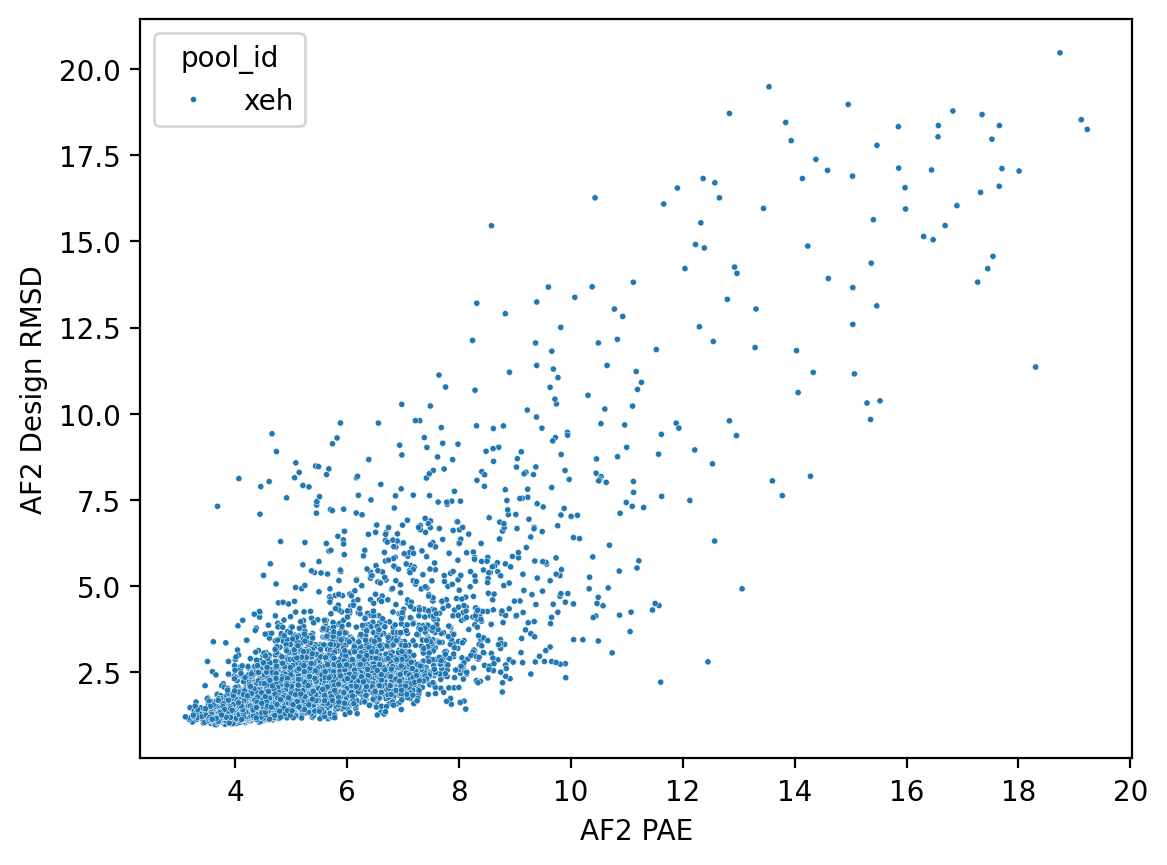

In [49]:
sns.scatterplot(designs, y='AF2 Design RMSD', x='AF2 PAE', hue='pool_id', s=5);

In [50]:
def plot_matrix(designs, thresholds):
    enabled_thresholds = [(k, t) for k, t in thresholds.items() if t.enabled]
    column_keys = [k for k, t in enabled_thresholds]
    column_descriptors = [descriptors.ALL_DESCRIPTORS_BY_KEY[k] for k in column_keys]
    column_names = [d.name for d in column_descriptors]
    g = sns.pairplot(designs[column_names + ['pool_id']], hue='pool_id', plot_kws=dict(s=5), diag_kind='hist');
    for i, (yd, (_, yt)) in enumerate(zip(column_descriptors, enabled_thresholds)):
        for j, (xd, (_, xt)) in enumerate(zip(column_descriptors, enabled_thresholds)):
            xbounds = xt.get_bounds(xd, designs[xd.name])
            ybounds = yt.get_bounds(yd, designs[yd.name])
            ax = g.axes[i][j]
            if i == j:
                ax.axvspan(*xbounds, alpha=0.2, color='#00ff00')
                continue
            assert ax.get_xlabel() == xd.name, f"{ax.get_xlabel()} != {xd.name}"
            assert ax.get_ylabel() == yd.name, f"{ax.get_ylabel()} != {yd.name}"
            ax.add_patch(plt.Rectangle((xbounds[0], ybounds[0]), xbounds[1]-xbounds[0], ybounds[1]-ybounds[0], alpha=0.2, color='#00ff00'))

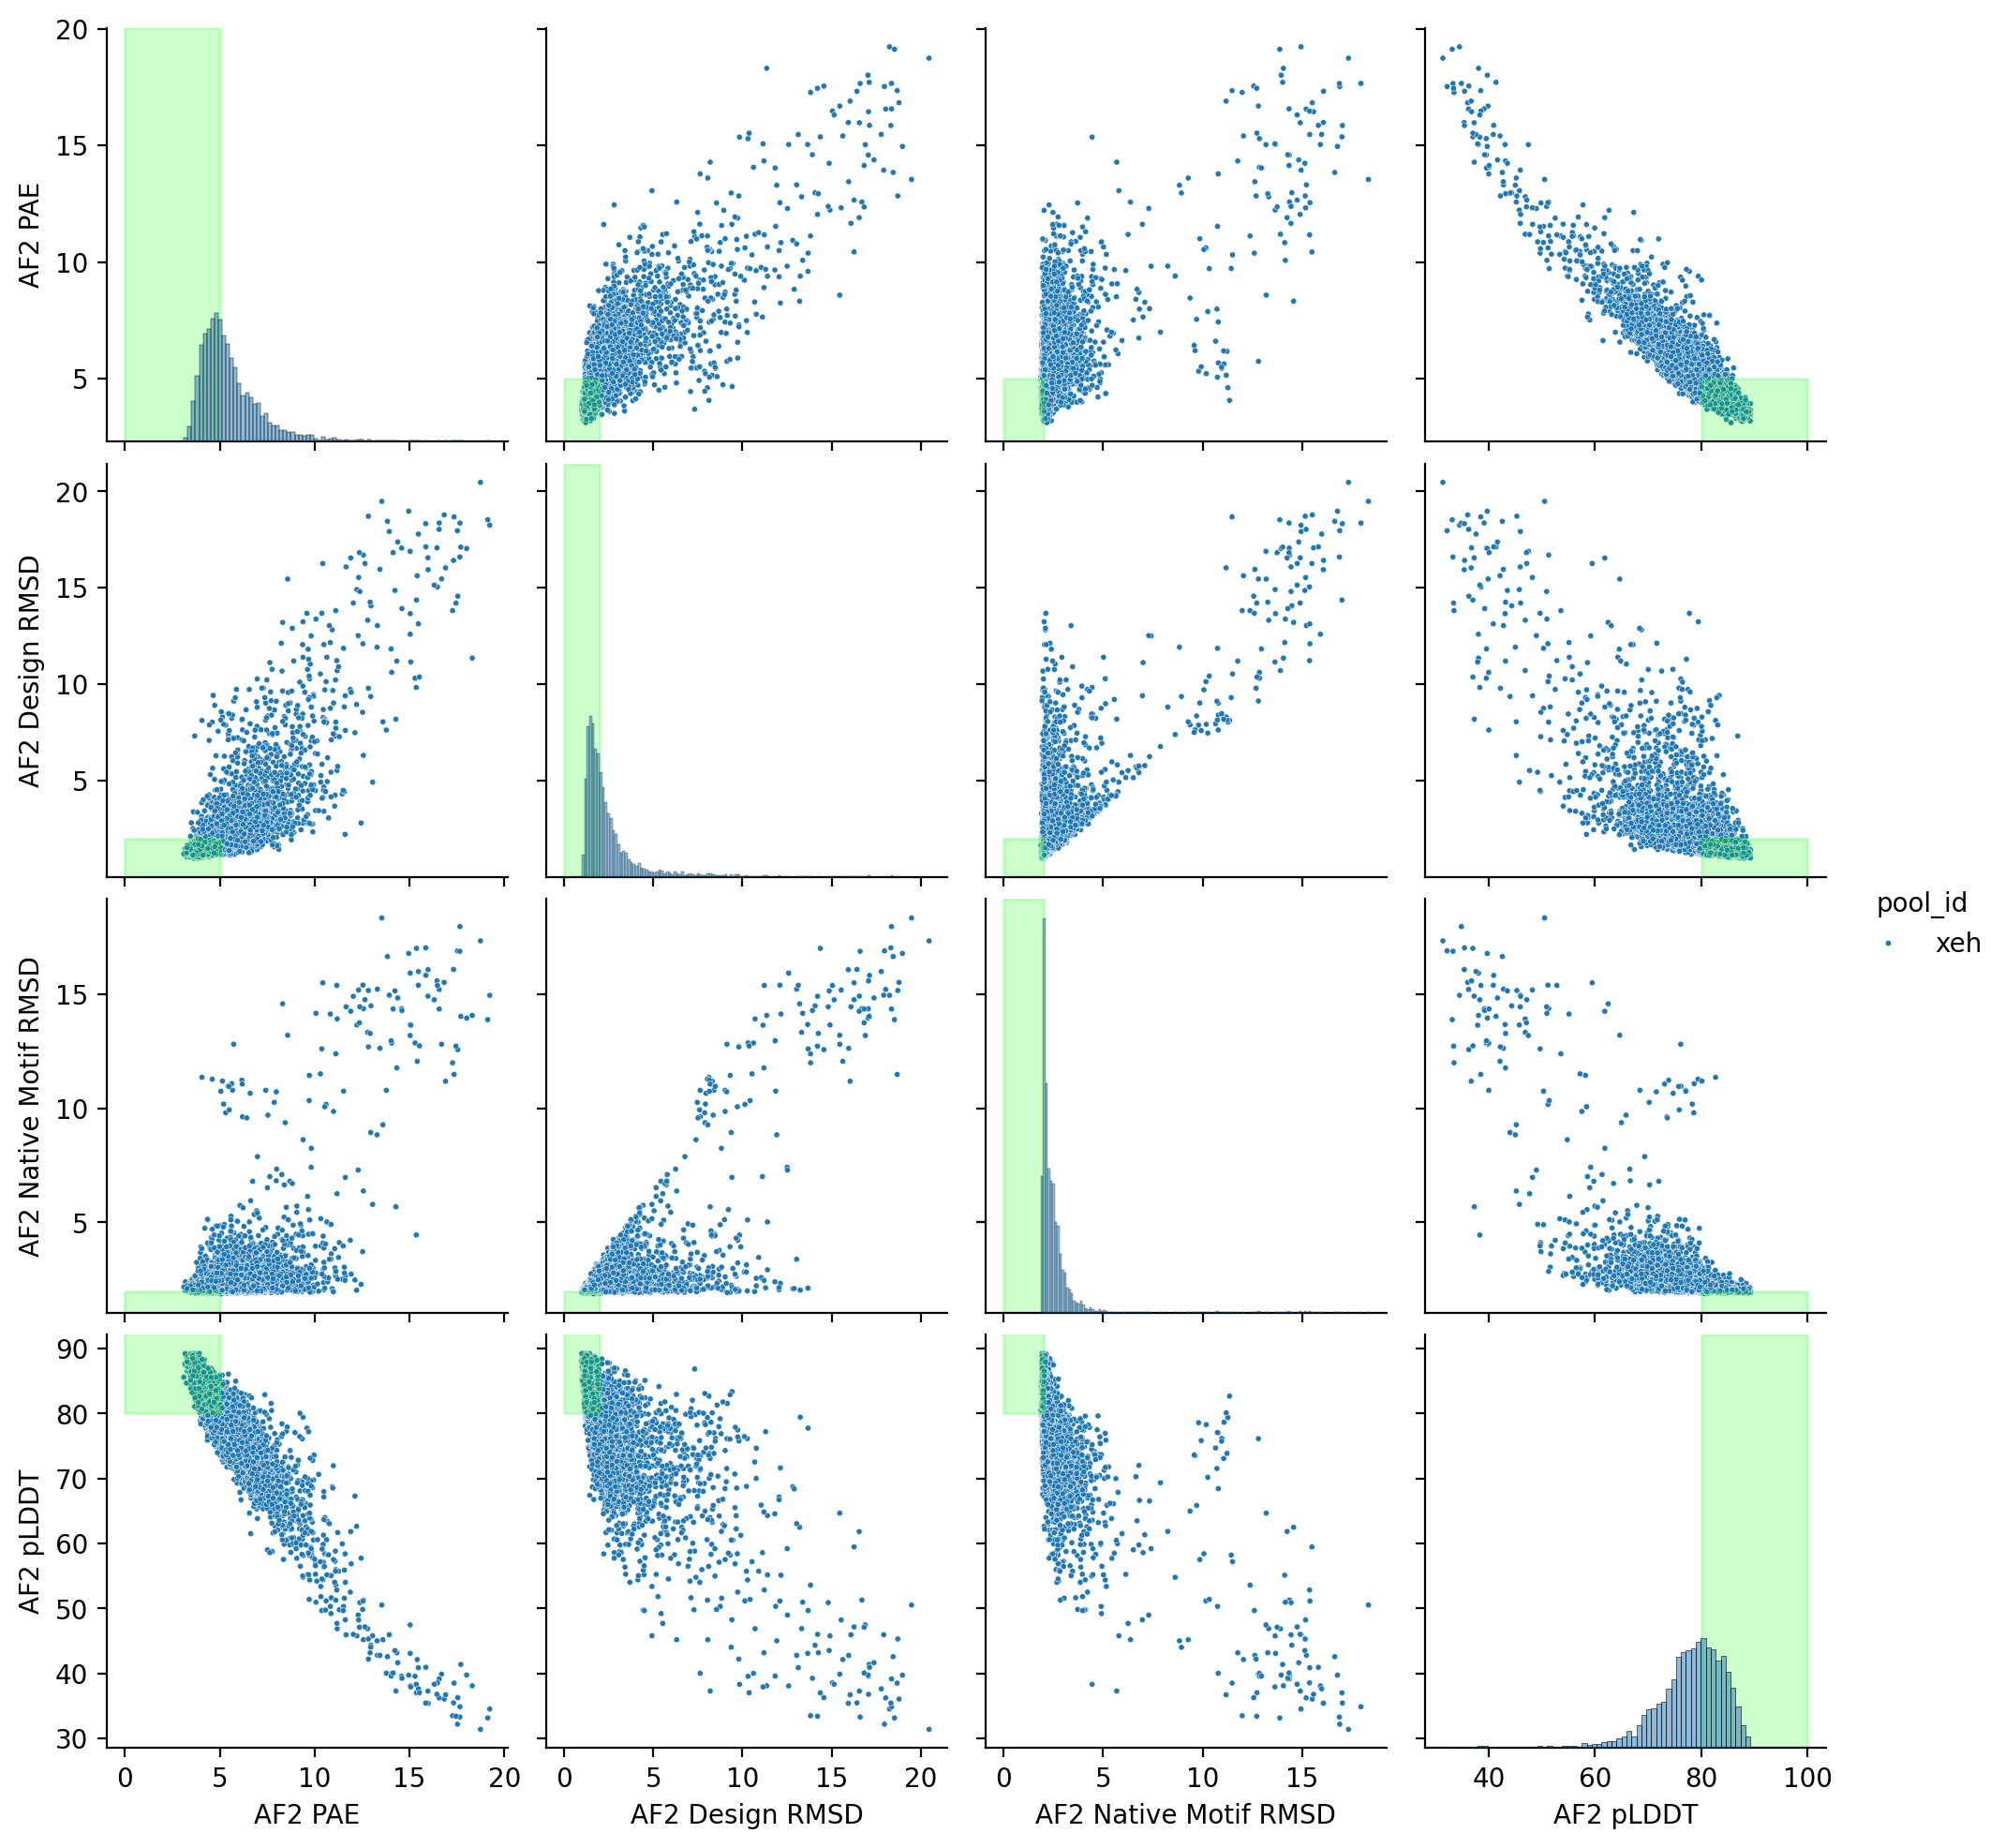

In [51]:
plot_matrix(designs, thresholds)

## Change acceptance thresholds

In [52]:
design_logic.update_acceptance_thresholds(pools=[pool], acceptance_thresholds=thresholds)

In [53]:
db.Design.count(accepted=True, pool_id=pool.id)

275